In [31]:
import pandas as pd

In [32]:
image_df = pd.read_csv('./../../data/image_analysis_data/yolo_update_data.csv')
full_df = pd.read_csv('./../../data/data_with_scraper.csv')

## NLP Features

In [33]:
full_df["title_char_len"]  = full_df["item_name"].str.len()
full_df["title_word_len"]  = full_df["item_name"].str.split().str.len()
full_df["title_avg_word"]  = full_df["title_char_len"] / full_df["title_word_len"]
full_df["sentiment_char_len"] = full_df["sd_customer_sentiments"].fillna("").str.len()

In [34]:
full_df["title_has_premium"] = full_df["item_name"].str.contains("premium|luxury|pro", case=False, na=False).astype(int)
full_df["title_has_set"]     = full_df["item_name"].str.contains("set|bundle|pack", case=False, na=False).astype(int)
full_df["title_has_new"]     = full_df["item_name"].str.contains("new|202|latest", case=False, na=False).astype(int)
full_df["title_has_size"]    = full_df["item_name"].str.contains(r"\d+\s?(ml|oz|pack|pcs)", case=False, na=False).astype(int)


/var/folders/8z/8s3q7km56flcrw0wjltczryh0000gn/T/ipykernel_36719/2846819866.py:4: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  full_df["title_has_size"]    = full_df["item_name"].str.contains(r"\d+\s?(ml|oz|pack|pcs)", case=False, na=False).astype(int)


In [35]:
import json
import pandas as pd

def extract_sentiment_counts(text):
    """
    text = string containing JSON list of sentiment dicts
    returns: dict with counts for POSITIVE, NEGATIVE, MIXED
    """
    if pd.isna(text) or text == "" or text == "[]":
        return pd.Series({
            "sent_pos": 0,
            "sent_neg": 0,
            "sent_mixed": 0,
            "sent_total": 0
        })

    try:
        data = json.loads(text)
        sentiments = [d.get("sentiment", "").upper() for d in data]

        pos = sum(s == "POSITIVE" for s in sentiments)
        neg = sum(s == "NEGATIVE" for s in sentiments)
        mixed = sum(s == "MIXED" for s in sentiments)

        total = pos + neg + mixed

        return pd.Series({
            "sent_pos": pos,
            "sent_neg": neg,
            "sent_mixed": mixed,
            "sent_total": total
        })

    except Exception:
        # If parsing fails, return zeros
        return pd.Series({
            "sent_pos": 0,
            "sent_neg": 0,
            "sent_mixed": 0,
            "sent_total": 0
        })

# Apply to your dataframe
sentiment_features = full_df["sd_customer_sentiments"].apply(extract_sentiment_counts)

full_df = pd.concat([full_df, sentiment_features], axis=1)


In [36]:
import textstat

full_df["title_readability"] = full_df["item_name"].fillna("").apply(textstat.flesch_reading_ease)
full_df["title_syllables"] = full_df["item_name"].fillna("").apply(textstat.syllable_count)


## Numeric Features
Now we select numeric features for modeling based on NLP feats, image feats, and the rest of the numerical features

In [37]:
# Drop junk column
full_df2 = full_df.drop(columns=["Unnamed: 0"], errors="ignore")

# Keep ASIN explicitly
full_numeric = pd.concat([
    full_df2[["asin"]],
    full_df2.select_dtypes(include=["number"])
], axis=1)


In [38]:
image_df2 = image_df.drop(columns=[ "Unnamed: 0", "keyword", "source_file",
                                    "item_name", "brand", "main_image_url",
                                    "product_url", "image_list", "image_path"
                                  ],
                          errors="ignore")

image_numeric = pd.concat([
    image_df2[["asin"]],
    image_df2.select_dtypes(include=["number"])
], axis=1)


In [39]:
final_df = (
    full_numeric
    .merge(image_numeric, on="asin", how="inner", suffixes=("_full", "_img"))
)

In [40]:
# now we drop fully nan columns
final_df = final_df.dropna(axis=1, how="all")
final_df.shape


(19336, 65)

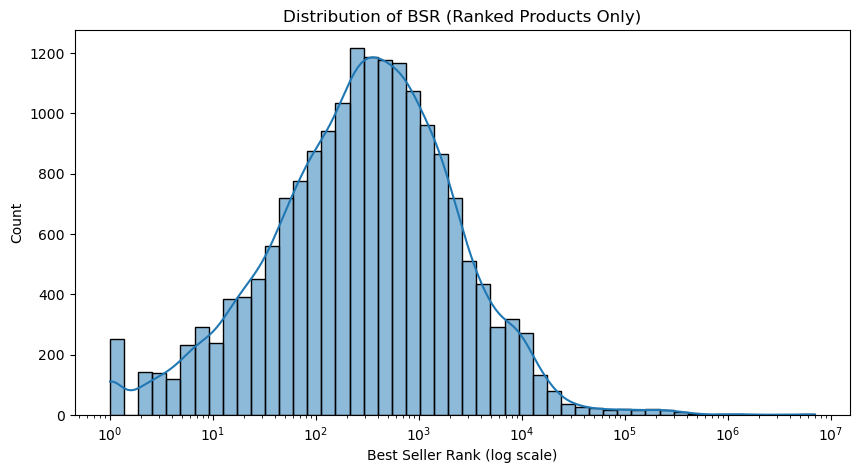

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract ranked values only
bsr = final_df['bsr_best_full'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(bsr, bins=50, kde=True, log_scale=True)
plt.title("Distribution of BSR (Ranked Products Only)")
plt.xlabel("Best Seller Rank (log scale)")
plt.ylabel("Count")
plt.show()


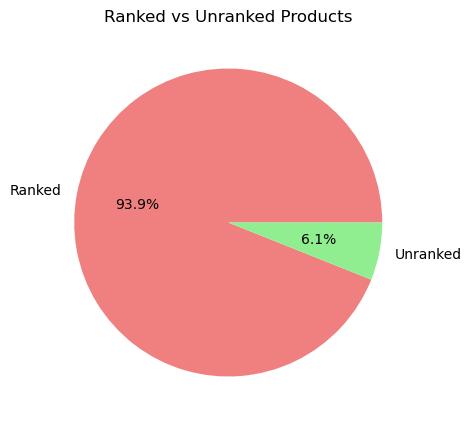

In [42]:
plt.figure(figsize=(5, 5))
final_df['bsr_best_full'].isna().value_counts().rename({True:"Unranked", False:"Ranked"}).plot.pie(
    autopct="%1.1f%%",
    colors=["lightcoral", "lightgreen"],
)
plt.title("Ranked vs Unranked Products")
plt.ylabel("")
plt.show()


# 1st Model: Classification of BSR

In [43]:
final_df["has_bsr_flag"] = final_df["bsr_best_full"].notna().astype(int)


In [44]:
leak_cols = [
    "bsr_best",
    "bsr_best_full",
    "bsr_best_img",
    "bsr_paths",
    "units_per_month",
    "sales_velocity_daily",
    "sd_number_bought_past_month",

    # Price-related (not available for new products)
    "sd_price",
    "sd_list_price",
    "sd_previous_price",

    # Review & rating leakage
    "sd_average_rating",
    "sd_total_reviews",
    "sd_ratings_count",
    "sd_stars",

    # Sentiment leakage
    "sent_pos",
    "sent_neg",
    "sent_mixed",
    "sent_total",
    "sentiment_char_len",
]


X = final_df.drop(columns=leak_cols + ["has_bsr_flag", "asin"], errors="ignore")


y = final_df["has_bsr_flag"]


In [45]:
X = X.fillna(0)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [47]:
X.columns

Index(['image_count_full', 'edge_density_full', 'bg_white_pct_full',
       'bg_neutral_pct_full', 'n_clusters_sig_full', 'color_entropy_full',
       'largest_cluster_pct_full', 'edge_density_z_full',
       'n_clusters_sig_z_full', 'color_entropy_z_full', 'bg_white_pct_z_full',
       'bg_neutral_pct_z_full', 'largest_cluster_pct_z_full',
       'clutter_score_full', 'title_char_len', 'title_word_len',
       'title_avg_word', 'title_has_premium', 'title_has_set', 'title_has_new',
       'title_has_size', 'title_readability', 'title_syllables',
       'image_count_img', 'edge_density_img', 'bg_white_pct_img',
       'bg_neutral_pct_img', 'n_clusters_sig_img', 'color_entropy_img',
       'largest_cluster_pct_img', 'edge_density_z_img', 'n_clusters_sig_z_img',
       'color_entropy_z_img', 'bg_white_pct_z_img', 'bg_neutral_pct_z_img',
       'largest_cluster_pct_z_img', 'clutter_score_img', 'n_objects',
       'category_diversity', 'has_person', 'sum_box_ratio',
       'product_box_rat

## Baseline model

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from xgboost import XGBClassifier

# -------------------------
# CLASSIFICATION SPLIT
# -------------------------
X_clf = X
y_clf = y

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    stratify=y_clf,
    random_state=42
)

# Imputer for logistic regression (classifier)
imputer_clf = SimpleImputer(strategy="median")
X_clf_train_lr = imputer_clf.fit_transform(X_clf_train)
X_clf_test_lr  = imputer_clf.transform(X_clf_test)

# -------------------------
# Logistic Regression baseline
# -------------------------
log_clf = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    n_jobs=-1
)
log_clf.fit(X_clf_train_lr, y_clf_train)

y_pred_log = log_clf.predict(X_clf_test_lr)
y_pred_log_proba = log_clf.predict_proba(X_clf_test_lr)[:, 1]

print("\n=== Logistic Regression Baseline (Median Imputed) ===")
print(classification_report(y_clf_test, y_pred_log))
print(confusion_matrix(y_clf_test, y_pred_log))


=== Logistic Regression Baseline (Median Imputed) ===
              precision    recall  f1-score   support

           0       0.14      0.63      0.23       234
           1       0.97      0.75      0.85      3634

    accuracy                           0.74      3868
   macro avg       0.55      0.69      0.54      3868
weighted avg       0.92      0.74      0.81      3868

[[ 148   86]
 [ 911 2723]]


/opt/anaconda3/envs/amazon-forecast/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
# -------------------------
# XGBoost classifier
# -------------------------
clf = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    scale_pos_weight=(y_clf_train.value_counts()[0] / y_clf_train.value_counts()[1]),
    n_jobs=4,
    random_state=42
)

clf.fit(X_clf_train, y_clf_train)

y_pred_xgb = clf.predict(X_clf_test)
y_pred_xgb_proba = clf.predict_proba(X_clf_test)[:, 1]

print("\n=== XGBoost Classifier ===")
print(classification_report(y_clf_test, y_pred_xgb))
print(confusion_matrix(y_clf_test, y_pred_xgb))



=== XGBoost Classifier ===
              precision    recall  f1-score   support

           0       0.32      0.63      0.43       234
           1       0.97      0.92      0.94      3634

    accuracy                           0.90      3868
   macro avg       0.65      0.77      0.69      3868
weighted avg       0.94      0.90      0.91      3868

[[ 147   87]
 [ 307 3327]]


results to be discussed later

# Now some feature importance

In [50]:
import pandas as pd

importance = clf.get_booster().get_score(importance_type='gain')

feat_imp = pd.DataFrame({
    'feature': list(importance.keys()),
    'importance': list(importance.values())
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)
feat_imp.head(20)


,feature,importance
23,image_count_img,13.247352
0,image_count_full,5.541752
19,title_has_new,4.683383
18,title_has_set,3.719188
35,largest_cluster_pct_z_img,3.709847
25,bg_white_pct_img,3.265517
10,bg_white_pct_z_full,2.751476
29,largest_cluster_pct_img,2.593882
30,edge_density_z_img,2.523613
22,title_syllables,2.507581


/var/folders/8z/8s3q7km56flcrw0wjltczryh0000gn/T/ipykernel_36719/2228812092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


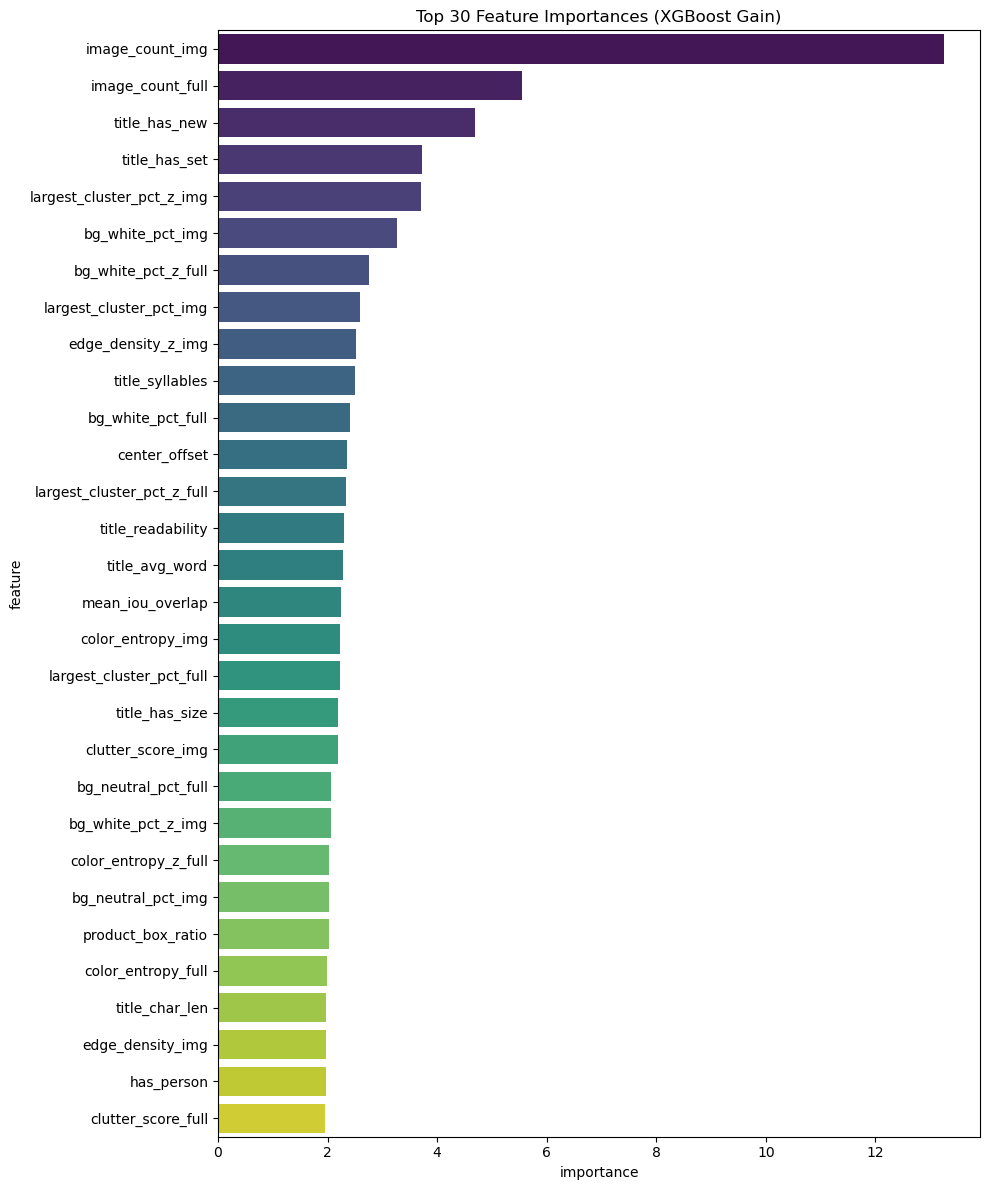

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 12))
sns.barplot(
    data=feat_imp.head(30),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title("Top 30 Feature Importances (XGBoost Gain)")
plt.tight_layout()
plt.show()


# Model 2: Regressing BSR rank itself

In [52]:
# Only ranked products
df_ranked = final_df[final_df["bsr_best_full"].notna()].copy()

# Same exact feature filter as classifier
X_reg = df_ranked.drop(columns=leak_cols + ["has_bsr_flag", "asin"], errors="ignore")

# Target: log-transformed BSR for stability
import numpy as np
y_reg = np.log1p(df_ranked["bsr_best_full"])


Multiple linear regression baseline

In [53]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import numpy as np

# -------------------------
# REGRESSION SPLIT
# -------------------------
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Imputer for linear regression baseline
imputer_reg = SimpleImputer(strategy="median")
X_reg_train_lr = imputer_reg.fit_transform(X_reg_train)
X_reg_test_lr  = imputer_reg.transform(X_reg_test)

# -------------------------
# Linear Regression baseline
# -------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_reg_train_lr, y_reg_train)

y_pred_lr = lin_reg.predict(X_reg_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2_lr = r2_score(y_reg_test, y_pred_lr)

print("=== Linear Regression Baseline ===")
print("RMSE (log-space):", rmse_lr)
print("R²:", r2_lr)

=== Linear Regression Baseline ===
RMSE (log-space): 2.0074812174706356
R²: 0.04254735966652268


In [54]:
# -------------------------
# XGBoost Regressor
# -------------------------
reg = XGBRegressor(
    n_estimators=500,
    max_depth=12,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=42
)

reg.fit(X_reg_train, y_reg_train)

# Use y_pred_reg_xgb to avoid overwriting classifier's y_pred_xgb
y_pred_reg_xgb = reg.predict(X_reg_test)

rmse_xgb = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_xgb))
r2_xgb = r2_score(y_reg_test, y_pred_reg_xgb)

print("=== XGBoost Regressor ===")
print("RMSE (log-space):", rmse_xgb)
print("R²:", r2_xgb)


=== XGBoost Regressor ===
RMSE (log-space): 1.75680017906624
R²: 0.26673821110006046


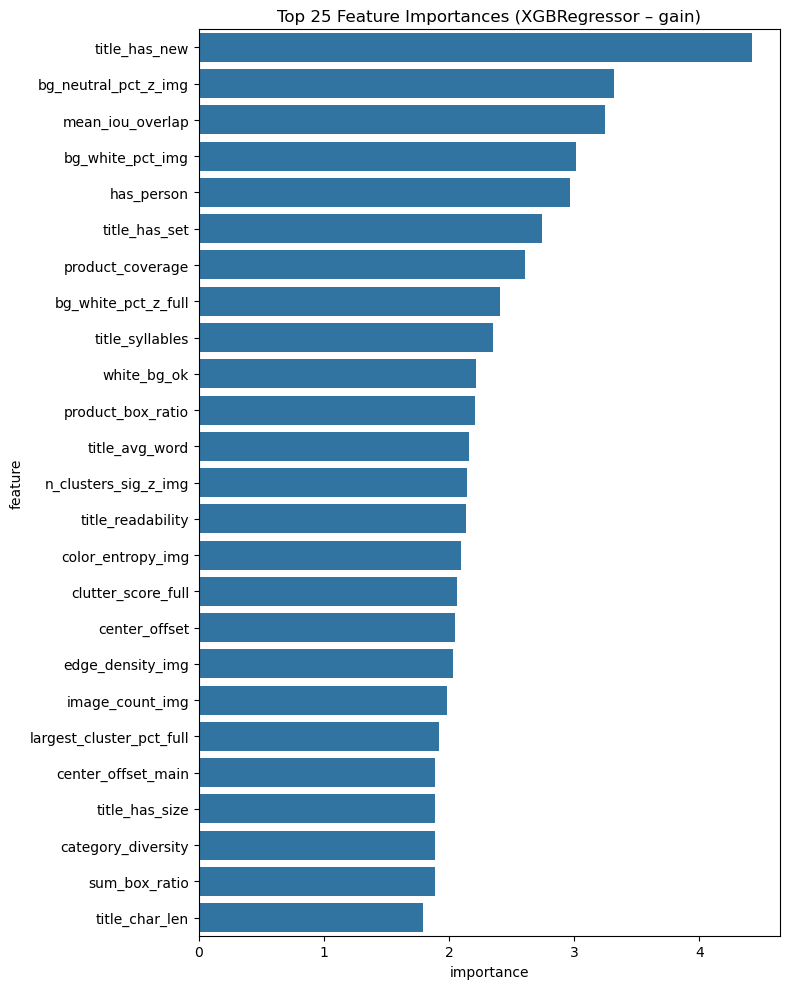

,feature,importance
19,title_has_new,4.422906
34,bg_neutral_pct_z_img,3.319265
43,mean_iou_overlap,3.241931
25,bg_white_pct_img,3.015179
39,has_person,2.965966
18,title_has_set,2.741142
44,product_coverage,2.609143
10,bg_white_pct_z_full,2.405216
22,title_syllables,2.347115
46,white_bg_ok,2.212727


In [55]:
import pandas as pd

imp_reg = reg.get_booster().get_score(importance_type='gain')
fi_reg = pd.DataFrame({
    "feature": list(imp_reg.keys()),
    "importance": list(imp_reg.values())
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8,10))
sns.barplot(
    data=fi_reg.head(25),
    x="importance",
    y="feature"
)
plt.title("Top 25 Feature Importances (XGBRegressor – gain)")
plt.tight_layout()
plt.show()

fi_reg.head(20)


RMSE (log space): 0.792377380756271
R²: 0.8496740724021541


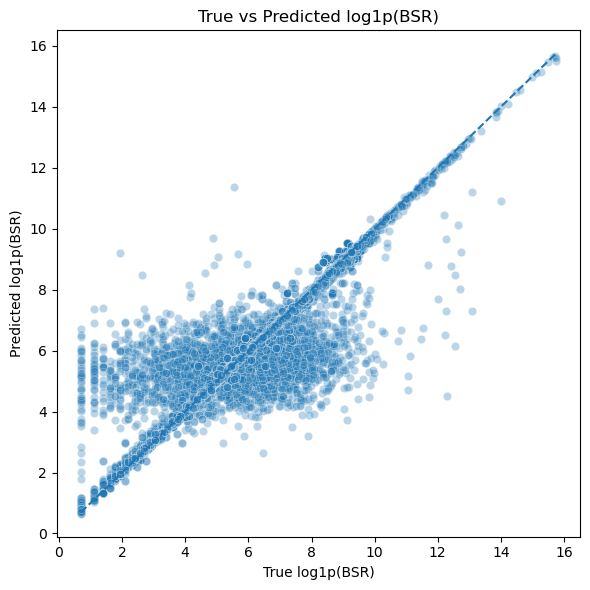

In [56]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = reg.predict(X_reg)
rmse = np.sqrt(mean_squared_error(y_reg, y_pred))
r2 = r2_score(y_reg, y_pred)
print("RMSE (log space):", rmse)
print("R²:", r2)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_reg, y=y_pred, alpha=0.3)
plt.plot([y_reg.min(), y_reg.max()],
         [y_reg.min(), y_reg.max()],
         linestyle="--")
plt.xlabel("True log1p(BSR)")
plt.ylabel("Predicted log1p(BSR)")
plt.title("True vs Predicted log1p(BSR)")
plt.tight_layout()
plt.show()


In [57]:
y_pred_test = reg.predict(X_reg_test)
rmse_test = np.sqrt(mean_squared_error(y_reg_test, y_pred_test))
r2_test = r2_score(y_reg_test, y_pred_test)

print("TEST RMSE:", rmse_test)
print("TEST R²:", r2_test)


TEST RMSE: 1.75680017906624
TEST R²: 0.26673821110006046


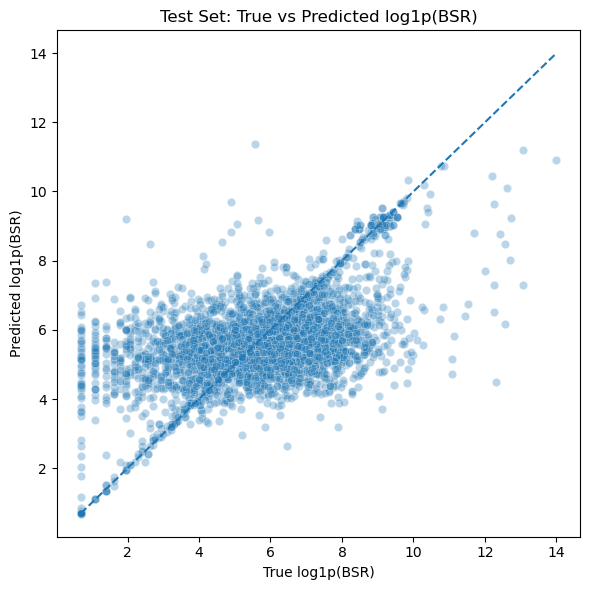

In [58]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_reg_test, y=y_pred_test, alpha=0.3)
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         linestyle="--")
plt.xlabel("True log1p(BSR)")
plt.ylabel("Predicted log1p(BSR)")
plt.title("Test Set: True vs Predicted log1p(BSR)")
plt.tight_layout()
plt.show()


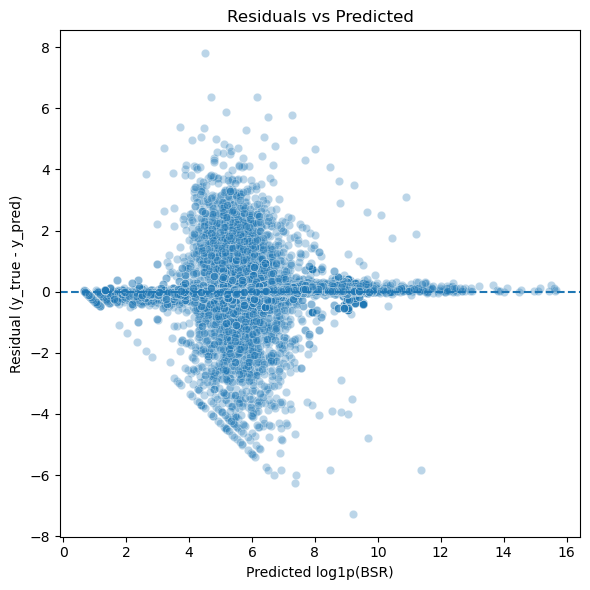

In [59]:
resid = y_reg - y_pred

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_pred, y=resid, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log1p(BSR)")
plt.ylabel("Residual (y_true - y_pred)")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.show()


# Model comparisons

In [60]:
clf_results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost Classifier"],
    "Accuracy": [
        accuracy_score(y_clf_test, y_pred_log),
        accuracy_score(y_clf_test, y_pred_xgb),
    ],
    "Precision": [
        precision_score(y_clf_test, y_pred_log),
        precision_score(y_clf_test, y_pred_xgb),
    ],
    "Recall": [
        recall_score(y_clf_test, y_pred_log),
        recall_score(y_clf_test, y_pred_xgb),
    ],
    "F1 Score": [
        f1_score(y_clf_test, y_pred_log),
        f1_score(y_clf_test, y_pred_xgb),
    ],
    "ROC AUC": [
        roc_auc_score(y_clf_test, y_pred_log_proba),
        roc_auc_score(y_clf_test, y_pred_xgb_proba),
    ]
})

print(clf_results)


                 Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
0  Logistic Regression  0.742244   0.969384  0.749312  0.845258  0.756246
1   XGBoost Classifier  0.898139   0.974517  0.915520  0.944098  0.849352


In [61]:
reg_results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost Regressor"],
    "RMSE (log BSR)": [rmse_lr, rmse_xgb],
    "R²": [r2_lr, r2_xgb]
})

print(reg_results)


               Model  RMSE (log BSR)        R²
0  Linear Regression        2.007481  0.042547
1  XGBoost Regressor        1.756800  0.266738


<Figure size 1000x600 with 0 Axes>

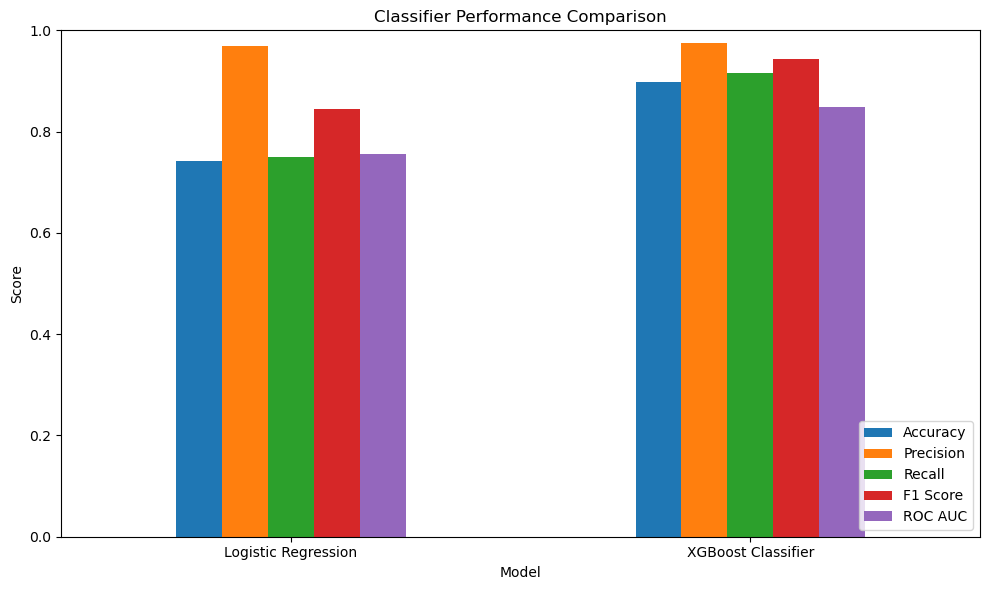

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
clf_results_m = clf_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]]

clf_results_m.plot(kind="bar", figsize=(10, 6))
plt.title("Classifier Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


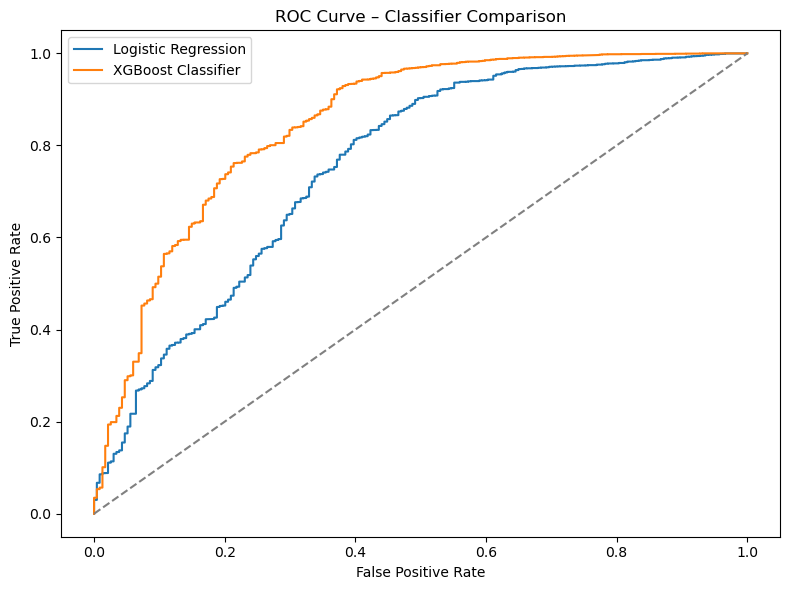

In [63]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_clf_test, y_pred_log_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_clf_test, y_pred_xgb_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label="Logistic Regression")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost Classifier")
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.title("ROC Curve – Classifier Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


## Prediction Confidence Analysis

This section analyzes prediction quality by stratifying predictions into high-confidence and low-confidence groups based on feature completeness and data quality indicators.


In [64]:
# Get test set indices to map back to original dataframe
from sklearn.model_selection import train_test_split

# Recreate the split to get indices
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Get the indices of test set
test_indices = X_reg_test.index

# Get the original dataframe rows for test set
df_test = df_ranked.loc[test_indices].copy()

# Get predictions for test set
y_pred_test = reg.predict(X_reg_test)

# Calculate residuals (errors)
residuals = y_reg_test - y_pred_test
abs_residuals = np.abs(residuals)

print(f"Test set size: {len(y_reg_test)}")
print(f"Overall RMSE: {rmse_test:.4f}")


Test set size: 3634
Overall RMSE: 1.7568


In [65]:
# Calculate confidence scores based on multiple factors
confidence_scores = []

for i, idx in enumerate(test_indices):
    # Get the feature vector for this sample (use positional index)
    sample_features = X_reg_test.iloc[i]
    
    # 1. Feature completeness: percentage of non-zero features
    non_zero_features = (sample_features != 0).sum()
    total_features = len(sample_features)
    feature_completeness = non_zero_features / total_features if total_features > 0 else 0
    
    # 2. Image count (if available)
    image_count = df_test.loc[idx, 'image_count'] if 'image_count' in df_test.columns else 0
    image_count_score = min(image_count / 8.0, 1.0)  # Normalize to max 8 images
    
    # 3. Clutter score (if available) - lower clutter = higher confidence
    if 'clutter_score' in df_test.columns:
        clutter = df_test.loc[idx, 'clutter_score']
        if pd.notna(clutter):
            # Normalize: lower clutter = higher confidence
            # Assuming clutter scores range roughly 0-1, invert it
            clutter_score = 1.0 - min(clutter, 1.0)
        else:
            clutter_score = 0.5  # Missing = medium confidence
    else:
        clutter_score = 0.5
    
    # 4. Distance from mean prediction (closer to mean = more typical = higher confidence)
    pred_value = y_pred_test[i]
    mean_pred = y_pred_test.mean()
    std_pred = y_pred_test.std()
    if std_pred > 0:
        distance_from_mean = abs(pred_value - mean_pred) / std_pred
        # Closer to mean = higher confidence (inverse relationship)
        mean_distance_score = 1.0 / (1.0 + distance_from_mean)
    else:
        mean_distance_score = 0.5
    
    # Combine scores (weighted average)
    confidence = (
        0.3 * feature_completeness +
        0.3 * image_count_score +
        0.2 * clutter_score +
        0.2 * mean_distance_score
    )
    
    confidence_scores.append(confidence)

confidence_scores = np.array(confidence_scores)

print(f"Confidence scores range: {confidence_scores.min():.3f} to {confidence_scores.max():.3f}")
print(f"Mean confidence: {confidence_scores.mean():.3f}")


Confidence scores range: 0.339 to 0.567
Mean confidence: 0.461


In [66]:
# Stratify predictions into high-confidence (top 25%) and low-confidence (bottom 25%)
confidence_75th = np.percentile(confidence_scores, 75)
confidence_25th = np.percentile(confidence_scores, 25)

high_conf_mask = confidence_scores >= confidence_75th
low_conf_mask = confidence_scores <= confidence_25th

y_test_high = y_reg_test[high_conf_mask]
y_pred_high = y_pred_test[high_conf_mask]
y_test_low = y_reg_test[low_conf_mask]
y_pred_low = y_pred_test[low_conf_mask]

print(f"High-confidence group (top 25%): {high_conf_mask.sum()} samples")
print(f"Low-confidence group (bottom 25%): {low_conf_mask.sum()} samples")


High-confidence group (top 25%): 909 samples
Low-confidence group (bottom 25%): 910 samples


In [67]:
# Calculate RMSE for each group
from sklearn.metrics import mean_squared_error

rmse_high = np.sqrt(mean_squared_error(y_test_high, y_pred_high))
rmse_low = np.sqrt(mean_squared_error(y_test_low, y_pred_low))
rmse_overall = rmse_test

# Calculate improvement percentages
improvement_high = ((rmse_overall - rmse_high) / rmse_overall) * 100
worsening_low = ((rmse_low - rmse_overall) / rmse_overall) * 100

print("="*70)
print("PREDICTION CONFIDENCE ANALYSIS")
print("="*70)
print(f"\nOverall RMSE: {rmse_overall:.4f}")
print(f"\nHigh-Confidence Predictions (Top 25%):")
print(f"  RMSE: {rmse_high:.4f} ({improvement_high:.1f}% better than overall)")
print(f"\nLow-Confidence Predictions (Bottom 25%):")
print(f"  RMSE: {rmse_low:.4f} ({worsening_low:.1f}% worse than overall)")


PREDICTION CONFIDENCE ANALYSIS

Overall RMSE: 1.7568

High-Confidence Predictions (Top 25%):
  RMSE: 1.8026 (-2.6% better than overall)

Low-Confidence Predictions (Bottom 25%):
  RMSE: 1.6577 (-5.6% worse than overall)


In [69]:
# Calculate percentage within 50% error margin for each group
# Error margin: |actual - predicted| / actual <= 0.5

# Convert from log space to original space for error calculation
# y_test_high is a Series, y_pred_high is already a numpy array
actual_high = np.expm1(y_test_high.values if hasattr(y_test_high, 'values') else y_test_high)
pred_high = np.expm1(y_pred_high)  # Already a numpy array
actual_low = np.expm1(y_test_low.values if hasattr(y_test_low, 'values') else y_test_low)
pred_low = np.expm1(y_pred_low)  # Already a numpy array

# Calculate relative errors
rel_error_high = np.abs(actual_high - pred_high) / actual_high
rel_error_low = np.abs(actual_low - pred_low) / actual_low

# Percentage within 50% error margin
within_50_high = (rel_error_high <= 0.5).sum() / len(rel_error_high) * 100
within_50_low = (rel_error_low <= 0.5).sum() / len(rel_error_low) * 100

# Overall
actual_overall = np.expm1(y_reg_test.values)
pred_overall = np.expm1(y_pred_test)
rel_error_overall = np.abs(actual_overall - pred_overall) / actual_overall
within_50_overall = (rel_error_overall <= 0.5).sum() / len(rel_error_overall) * 100

print(f"\nPercentage within 50% error margin:")
print(f"  Overall: {within_50_overall:.1f}%")
print(f"  High-Confidence: {within_50_high:.1f}%")
print(f"  Low-Confidence: {within_50_low:.1f}%")



Percentage within 50% error margin:
  Overall: 34.3%
  High-Confidence: 28.8%
  Low-Confidence: 44.7%
